# 05e — CLEAR Adjacent Amino Acid Pair Energy Scoring

## Obiettivo

Implementare una funzione interpretabile che assegni un **costo empirico posizione-specifico** alle coppie di amminoacidi adiacenti:

\[
C_{pair}(s)=\sum_{i=1}^{L-1} C_i(a_i,a_{i+1})
\]

Il costo viene stimato dal dataset locale 04c e confrontato con le combinazioni alternative osservate o consentite alla stessa posizione.

> Il valore ottenuto è un **surrogate energetic cost**, non una energia fisica assoluta in kcal/mol.

Il notebook confronta F0010 e i candidati finali del 05d, integra FoldX/Rosetta e produce una funzione riutilizzabile per futuri workflow di docking e ottimizzazione.

In [1]:
from pathlib import Path
from itertools import product
import ast, json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 220)
pd.set_option("display.max_colwidth", 180)
print("Ambiente inizializzato.")

Ambiente inizializzato.


## 1. Configurazione

In [2]:
OUTPUT_DIR = Path("outputs")

DATASET_CANDIDATES = [
    OUTPUT_DIR / "clear_local_peptide_dataset_04c" / "clear_local_peptide_variant_dataset_labeled.csv",
    OUTPUT_DIR / "clear_local_peptide_dataset_04c" / "clear_local_peptide_variant_dataset.csv",
]
CONSTRAINT_CANDIDATES = [
    OUTPUT_DIR / "clear_local_peptide_dataset_04c" / "library" / "clear_position_constraints.csv",
    OUTPUT_DIR / "clear_local_peptide_dataset_04c" / "clear_position_constraints.csv",
]
RANKING_05D = OUTPUT_DIR / "clear_counterfactual_flexpepdock_05d" / "clear_counterfactual_flexpepdock_final_ranking.csv"
VALIDATION_05C = OUTPUT_DIR / "clear_counterfactual_validation_05c" / "clear_counterfactual_foldx_structural_validation.csv"

RESULT_DIR = OUTPUT_DIR / "clear_adjacent_pair_scoring_05e"
REPORTS_DIR = RESULT_DIR / "reports"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SEED_ID = "F0010"
SEED_SEQUENCE = "IGERCQYRDLK"
PAIR_SHRINKAGE_ALPHA = 3.0
MIN_PAIR_SUPPORT = 2
NORMALIZE_TOTAL_BY_LENGTH = True

print("Output:", RESULT_DIR.resolve())

Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e


## 2. Individuazione degli input

In [3]:
def first_existing(paths):
    return next((p for p in paths if p.exists()), None)

DATASET_04C = first_existing(DATASET_CANDIDATES)
CONSTRAINTS_04C = first_existing(CONSTRAINT_CANDIDATES)

if DATASET_04C is None:
    matches = sorted(OUTPUT_DIR.rglob("*clear*variant*dataset*labeled*.csv"))
    if not matches:
        matches = sorted(OUTPUT_DIR.rglob("*clear*variant*dataset*.csv"))
    DATASET_04C = matches[0] if matches else None

if DATASET_04C is None:
    raise FileNotFoundError("Dataset 04c non trovato.")
if not RANKING_05D.exists():
    raise FileNotFoundError("Ranking finale 05d non trovato.")

print("Dataset 04c:", DATASET_04C.resolve())
print("Vincoli 04c:", CONSTRAINTS_04C.resolve() if CONSTRAINTS_04C else "non trovati")
print("Ranking 05d:", RANKING_05D.resolve())

Dataset 04c: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv
Vincoli 04c: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/library/clear_position_constraints.csv
Ranking 05d: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_flexpepdock_05d/clear_counterfactual_flexpepdock_final_ranking.csv


## 3. Caricamento del dataset e riconoscimento delle colonne

In [4]:
dataset = pd.read_csv(DATASET_04C)

sequence_candidates = ["sequence", "mutant_sequence", "variant_sequence", "peptide_sequence"]
target_candidates = [
    "oracle_target_composite_preliminary", "target", "label",
    "composite_score", "energetic_score"
]
SEQUENCE_COLUMN = next((x for x in sequence_candidates if x in dataset.columns), None)
TARGET_COLUMN = next((x for x in target_candidates if x in dataset.columns), None)

if SEQUENCE_COLUMN is None:
    raise ValueError("Colonna della sequenza non riconosciuta.")
if TARGET_COLUMN is None:
    preferred = [x for x in dataset.select_dtypes(include=[np.number]).columns
                 if any(k in x.lower() for k in ["target", "score", "label"])]
    if not preferred:
        raise ValueError("Target energetico/composito non riconosciuto.")
    TARGET_COLUMN = preferred[0]

dataset = dataset[dataset[SEQUENCE_COLUMN].astype(str).str.len() == len(SEED_SEQUENCE)].copy()
dataset[TARGET_COLUMN] = pd.to_numeric(dataset[TARGET_COLUMN], errors="coerce")
dataset = dataset.dropna(subset=[SEQUENCE_COLUMN, TARGET_COLUMN]).reset_index(drop=True)

print("Colonna sequenza:", SEQUENCE_COLUMN)
print("Colonna target:", TARGET_COLUMN)
print("Varianti utilizzabili:", len(dataset))
display(dataset.head())

Colonna sequenza: sequence
Colonna target: oracle_target_composite_preliminary
Varianti utilizzabili: 539


,variant_id,variant_type,sequence,n_mutations,mutation_labels,foldx_mutation_string,mutated_sequence_positions,mutated_resseqs,n_mutated_hotspots,all_mutations_conservative,filter_status,passes_filters,net_charge_proxy,hydrophobic_fraction,aromatic_fraction,polar_fraction,positive_fraction,negative_fraction,glycine_count,proline_count,cysteine_count,max_identical_run,hamming_distance_from_seed,chunk_id,foldx_ddG_total_kcal_mol,foldx_energy_parse_status,foldx_raw_line,variant_model_pdb,model_status,structural_parse_status,n_atom_contacts_4p5A,n_residue_contacts_4p5A,n_peptide_contact_residues,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_hotspots_in_contact,min_interchain_distance_A,n_atom_clashes_lt_2A,norm_favorable_foldx_ddG,norm_native_contact_recall,norm_hotspot_preservation,clash_penalty,oracle_target_composite_preliminary,has_complete_foldx_label
0,V00000,seed,IGERCQYRDLK,0,NaN,NaN,NaN,NaN,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,0,NaN,0.000000,SEED_REFERENCE,NaN,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb,SEED_REFERENCE,SEED_REFERENCE,185.0,37.0,10.0,0.909091,1.000000,1.000000,1.0,6.0,2.602119,0.0,0.717263,1.000,0.5,0.0,0.758631,True
1,V00001,single,AGERCQYRDLK,1,I1A,ID38A;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,0.463630,PARSED_BY_ORDER,F0010_native_complex_1.pdb\t0.46363\t0.346148\t1.02638\t0.711639\t-0.416927\t-1.00581\t0.999032\t0.0861055\t-1.51489\t0.265597\t0\t0\t0\t-0.0911063\t0.138896\t-0.0210033\t0\t0\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00001.pdb,MODEL_AVAILABLE,OK,173.0,35.0,10.0,0.909091,0.945946,1.000000,1.0,6.0,2.602119,0.0,0.654662,0.750,0.5,0.0,0.652331,True
2,V00002,single,FGERCQYRDLK,1,I1F,ID38F;,1,38,0,False,PASS,True,1,0.272727,0.181818,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,0.371447,PARSED_BY_ORDER,F0010_native_complex_2.pdb\t0.371447\t0.377605\t1.05869\t-0.181123\t0.49995\t-0.258039\t-0.429134\t-0.0251336\t-0.587722\t0.0633776\t0\t0\t0\t-0.144454\t-0.116356\t-0.00272559\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00002.pdb,MODEL_AVAILABLE,OK,197.0,37.0,10.0,0.909091,0.945946,0.945946,1.0,6.0,2.602119,0.0,0.667109,0.750,0.5,0.0,0.658555,True
3,V00003,single,LGERCQYRDLK,1,I1L,ID38L;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,-0.033391,PARSED_BY_ORDER,F0010_native_complex_3.pdb\t-0.0333914\t-0.279508\t-0.300106\t-0.533883\t0.513429\t1.1222\t-0.527678\t0.181744\t0.355015\t-0.0665884\t0\t0\t0\t-0.502683\t0.17036\t0.00555312\t0...,outputs/clear_local_peptide_dataset_04c/variant_models/V00003.pdb,MODEL_AVAILABLE,OK,191.0,38.0,10.0,0.909091,0.972973,0.947368,1.0,6.0,2.602119,0.0,0.721772,0.875,0.5,0.0,0.723386,True
4,V00004,single,MGERCQYRDLK,1,I1M,ID38M;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,-0.310250,PARSED_BY_ORDER,F0010_native_complex_4.pdb\t-0.31025\t-0.0172325\t-0.0104792\t-0.551273\t0.110236\t0.617606\t-0.634628\t0.0257439\t0.639171\t0.195687\t0\t0\t0\t-0.713999\t0.148453\t0.00342027\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00004.pdb,MODEL_AVAILABLE,OK,175.0,37.0,10.0,0.909091,0.972973,0.972973,1.0,6.0,2.602119,0.0,0.759154,0.875,0.5,0.0,0.742077,True


## 4. Estrazione delle coppie e convenzione del costo

Il target 04c usa la convenzione **maggiore = più favorevole**. Il costo viene quindi definito come:

\[
C_i(pair)=\mu_i-\hat{\mu}_{i,pair}
\]

- costo negativo: coppia favorevole;
- costo positivo: coppia sfavorevole;
- costo circa zero: comportamento vicino alla media della posizione.

In [5]:
rows = []
for variant_index, row in dataset.iterrows():
    seq = str(row[SEQUENCE_COLUMN])
    target = float(row[TARGET_COLUMN])
    for i in range(len(seq)-1):
        rows.append({
            "variant_index": variant_index,
            "sequence": seq,
            "target_value": target,
            "pair_position_1based": i+1,
            "left_position_1based": i+1,
            "right_position_1based": i+2,
            "aa_left": seq[i],
            "aa_right": seq[i+1],
            "pair": seq[i:i+2],
        })
pair_observations = pd.DataFrame(rows)
print("Osservazioni di coppia:", len(pair_observations))
display(pair_observations.head(15))

Osservazioni di coppia: 5390


,variant_index,sequence,target_value,pair_position_1based,left_position_1based,right_position_1based,aa_left,aa_right,pair
0,0,IGERCQYRDLK,0.758631,1,1,2,I,G,IG
1,0,IGERCQYRDLK,0.758631,2,2,3,G,E,GE
2,0,IGERCQYRDLK,0.758631,3,3,4,E,R,ER
3,0,IGERCQYRDLK,0.758631,4,4,5,R,C,RC
4,0,IGERCQYRDLK,0.758631,5,5,6,C,Q,CQ
5,0,IGERCQYRDLK,0.758631,6,6,7,Q,Y,QY
6,0,IGERCQYRDLK,0.758631,7,7,8,Y,R,YR
7,0,IGERCQYRDLK,0.758631,8,8,9,R,D,RD
8,0,IGERCQYRDLK,0.758631,9,9,10,D,L,DL
9,0,IGERCQYRDLK,0.758631,10,10,11,L,K,LK


## 5. Stima regolarizzata dei costi posizione-specifici

In [6]:
position_baseline = (
    pair_observations.groupby("pair_position_1based")["target_value"]
    .agg(position_target_mean="mean", position_target_std="std", position_n="size")
    .reset_index()
)

pair_statistics = (
    pair_observations.groupby([
        "pair_position_1based", "left_position_1based", "right_position_1based",
        "aa_left", "aa_right", "pair"
    ])["target_value"]
    .agg(pair_target_mean="mean", pair_target_std="std", pair_support="size", pair_target_median="median")
    .reset_index()
    .merge(position_baseline, on="pair_position_1based", how="left")
)

pair_statistics["shrunk_pair_target"] = (
    pair_statistics["pair_support"] * pair_statistics["pair_target_mean"]
    + PAIR_SHRINKAGE_ALPHA * pair_statistics["position_target_mean"]
) / (pair_statistics["pair_support"] + PAIR_SHRINKAGE_ALPHA)
pair_statistics["pair_cost"] = pair_statistics["position_target_mean"] - pair_statistics["shrunk_pair_target"]
pair_statistics["pair_advantage"] = -pair_statistics["pair_cost"]
pair_statistics["reliable_support"] = pair_statistics["pair_support"] >= MIN_PAIR_SUPPORT
pair_statistics["rank_within_position"] = (
    pair_statistics.groupby("pair_position_1based")["pair_cost"]
    .rank(method="dense", ascending=True).astype(int)
)
display(pair_statistics.sort_values(["pair_position_1based", "pair_cost"]).head(30))

,pair_position_1based,left_position_1based,right_position_1based,aa_left,aa_right,pair,pair_target_mean,pair_target_std,pair_support,pair_target_median,position_target_mean,position_target_std,position_n,shrunk_pair_target,pair_cost,pair_advantage,reliable_support,rank_within_position
3,1,1,2,L,G,LG,0.635302,0.122126,33,0.679158,0.608728,0.126187,539,0.633088,-0.024360,0.024360,True,1
5,1,1,2,T,G,TG,0.626781,0.108277,32,0.645095,0.608728,0.126187,539,0.625233,-0.016506,0.016506,True,2
4,1,1,2,M,G,MG,0.612942,0.100656,32,0.632866,0.608728,0.126187,539,0.612581,-0.003853,0.003853,True,3
2,1,1,2,I,G,IG,0.609547,0.132915,350,0.630171,0.608728,0.126187,539,0.609540,-0.000812,0.000812,True,4
6,1,1,2,V,G,VG,0.602818,0.104677,32,0.608970,0.608728,0.126187,539,0.603325,0.005403,-0.005403,True,5
1,1,1,2,F,G,FG,0.598681,0.121605,29,0.621968,0.608728,0.126187,539,0.599623,0.009105,-0.009105,True,6
0,1,1,2,A,G,AG,0.563700,0.114183,31,0.582298,0.608728,0.126187,539,0.567673,0.041054,-0.041054,True,7
8,2,2,3,G,E,GE,0.616800,0.130712,386,0.649483,0.608728,0.126187,539,0.616738,-0.008010,0.008010,True,1
12,2,2,3,G,R,GR,0.602279,0.113384,26,0.626981,0.608728,0.126187,539,0.602946,0.005782,-0.005782,True,2
7,2,2,3,G,D,GD,0.593573,0.116622,33,0.631133,0.608728,0.126187,539,0.594836,0.013891,-0.013891,True,3


## 6. Vincoli CLEAR e combinazioni alternative

In [20]:
AA_ALPHABET = list("ACDEFGHIKLMNPQRSTVWY")
def parse_allowed_value(value):
    if pd.isna(value):
        return []

    if isinstance(value, (list, tuple, set)):
        values = list(value)
    else:
        text = str(value).strip()

        try:
            parsed = ast.literal_eval(text)

            if isinstance(parsed, (list, tuple, set)):
                values = list(parsed)
            else:
                values = [parsed]

        except Exception:
            values = re.findall(
                r"[ACDEFGHIKLMNPQRSTVWY]",
                text.upper(),
            )

    allowed = []

    for value in values:
        aa = str(value).strip().upper()

        if len(aa) == 1 and aa in AA_ALPHABET:
            allowed.append(aa)

    return sorted(set(allowed))


allowed_by_position = {
    position: [wildtype]
    for position, wildtype in enumerate(
        SEED_SEQUENCE,
        start=1,
    )
}

if CONSTRAINTS_04C is None:
    raise FileNotFoundError(
        "File clear_position_constraints.csv non trovato."
    )

constraints = pd.read_csv(CONSTRAINTS_04C)

print("Colonne del file dei vincoli:")
print(constraints.columns.tolist())

required_constraint_columns = {
    "sequence_position_1based",
    "wildtype_aa",
    "allowed_substitutions",
}

missing = (
    required_constraint_columns
    - set(constraints.columns)
)

if missing:
    raise ValueError(
        "Colonne mancanti nel file dei vincoli: "
        + ", ".join(sorted(missing))
    )

for _, row in constraints.iterrows():
    position = int(
        row["sequence_position_1based"]
    )

    wildtype = str(
        row["wildtype_aa"]
    ).strip().upper()

    substitutions = parse_allowed_value(
        row["allowed_substitutions"]
    )

    # Le alternative includono sempre anche
    # il residuo wild-type.
    allowed = sorted(
        set([wildtype] + substitutions)
    )

    allowed_by_position[position] = allowed


print("\nAlternative consentite per posizione:")

for position in sorted(allowed_by_position):
    wildtype = SEED_SEQUENCE[position - 1]

    print(
        f"{position:2d}",
        f"WT={wildtype}",
        f"allowed={allowed_by_position[position]}",
    )

Colonne del file dei vincoli:
['sequence_position_1based', 'chain', 'resseq', 'wildtype_aa', 'is_hotspot', 'alanine_scan_ddG_kcal_mol', 'position_class', 'allowed_substitutions', 'n_allowed_substitutions']

Alternative consentite per posizione:
 1 WT=I allowed=['A', 'F', 'I', 'L', 'M', 'T', 'V']
 2 WT=G allowed=['G']
 3 WT=E allowed=['D', 'E', 'K', 'N', 'Q', 'R']
 4 WT=R allowed=['R']
 5 WT=C allowed=['C', 'S', 'T']
 6 WT=Q allowed=['E', 'N', 'Q', 'R', 'T']
 7 WT=Y allowed=['F', 'H', 'T', 'W', 'Y']
 8 WT=R allowed=['H', 'K', 'Q', 'R']
 9 WT=D allowed=['D', 'E', 'N', 'Q']
10 WT=L allowed=['A', 'F', 'I', 'L', 'M', 'T', 'V']
11 WT=K allowed=['E', 'H', 'K', 'N', 'Q', 'R']


## 7. Funzione di scoring riutilizzabile

In [21]:
pair_cost_lookup = {
    (int(r.pair_position_1based), str(r.pair)): {
        "pair_cost": float(r.pair_cost),
        "pair_advantage": float(r.pair_advantage),
        "pair_support": int(r.pair_support),
        "rank_within_position": int(r.rank_within_position),
        "observed": True,
    }
    for r in pair_statistics.itertuples(index=False)
}

def score_pair(position, pair):
    return pair_cost_lookup.get((int(position), str(pair)), {
        "pair_cost": 0.0, "pair_advantage": 0.0, "pair_support": 0,
        "rank_within_position": np.nan, "observed": False,
    })

def score_sequence(sequence):
    if len(sequence) != len(SEED_SEQUENCE):
        raise ValueError(f"Lunghezza non valida: {sequence}")
    rows = []
    for i in range(len(sequence)-1):
        pair = sequence[i:i+2]
        rows.append({
            "pair_position_1based": i+1,
            "left_position_1based": i+1,
            "right_position_1based": i+2,
            "pair": pair,
            **score_pair(i+1, pair),
        })
    details = pd.DataFrame(rows)
    total = details["pair_cost"].sum()
    if NORMALIZE_TOTAL_BY_LENGTH:
        total /= len(details)
    return {
        "pair_total_cost": float(total),
        "pair_mean_cost": float(details["pair_cost"].mean()),
        "pair_min_cost": float(details["pair_cost"].min()),
        "pair_max_cost": float(details["pair_cost"].max()),
        "n_observed_pairs": int(details["observed"].sum()),
        "n_unobserved_pairs": int((~details["observed"]).sum()),
        "mean_pair_support": float(details["pair_support"].mean()),
        "contributions": details,
    }

def adjacent_pair_energy_score(sequence, return_details=False):
    result = score_sequence(sequence)
    return result if return_details else result["pair_total_cost"]

print("F0010 score:", adjacent_pair_energy_score(SEED_SEQUENCE))

F0010 score: -0.002426987482090903


## 8. Pair score dei candidati finali del 05d

In [22]:
ranking_05d = pd.read_csv(RANKING_05D)
if not {"candidate_id", "sequence"}.issubset(ranking_05d.columns):
    raise ValueError("Il ranking 05d non contiene candidate_id e sequence.")

if SEED_ID not in set(ranking_05d["candidate_id"]):
    ranking_05d = pd.concat([
        pd.DataFrame([{"candidate_id": SEED_ID, "sequence": SEED_SEQUENCE, "mutation_labels": "seed_reference"}]),
        ranking_05d
    ], ignore_index=True)

summary_rows, contribution_frames = [], []
for row in ranking_05d.itertuples(index=False):
    result = score_sequence(row.sequence)
    summary_rows.append({
        "candidate_id": row.candidate_id,
        "sequence": row.sequence,
        "mutation_labels": getattr(row, "mutation_labels", ""),
        **{k:v for k,v in result.items() if k != "contributions"},
    })
    detail = result["contributions"].copy()
    detail.insert(0, "candidate_id", row.candidate_id)
    detail.insert(1, "sequence", row.sequence)
    contribution_frames.append(detail)

candidate_pair_scores = pd.DataFrame(summary_rows)
pair_contributions = pd.concat(contribution_frames, ignore_index=True)
seed_cost = candidate_pair_scores.loc[candidate_pair_scores["candidate_id"] == SEED_ID, "pair_total_cost"].iloc[0]
candidate_pair_scores["delta_pair_cost_vs_seed"] = candidate_pair_scores["pair_total_cost"] - seed_cost
candidate_pair_scores["pair_better_than_seed"] = candidate_pair_scores["delta_pair_cost_vs_seed"] < 0
candidate_pair_scores = candidate_pair_scores.sort_values("pair_total_cost").reset_index(drop=True)
candidate_pair_scores.insert(0, "pair_rank", np.arange(1, len(candidate_pair_scores)+1))
display(candidate_pair_scores)

,pair_rank,candidate_id,sequence,mutation_labels,pair_total_cost,pair_mean_cost,pair_min_cost,pair_max_cost,n_observed_pairs,n_unobserved_pairs,mean_pair_support,delta_pair_cost_vs_seed,pair_better_than_seed
0,1,CF_05,IGERCEYRELK,Q6E;D9E,-0.046202,-0.046202,-0.134834,0.009776,10,0,236.7,-0.043775,True
1,2,CF_02,IGERSQYRELK,C5S;D9E,-0.042063,-0.042063,-0.134834,0.009776,10,0,229.3,-0.039636,True
2,3,CF_06,IGERCQYRELR,D9E;K11R,-0.030316,-0.030316,-0.134834,0.010913,10,0,283.1,-0.027889,True
3,4,CF_10,IGERCQYRELQ,D9E;K11Q,-0.027985,-0.027985,-0.134834,0.010913,10,0,283.1,-0.025558,True
4,5,CF_03,IGERCQYRELK,D9E,-0.025227,-0.025227,-0.134834,0.010913,10,0,308.4,-0.022800,True
5,6,F0010,IGERCQYRDLK,seed_reference,-0.002427,-0.002427,-0.030881,0.020702,10,0,373.2,0.000000,False


## 9. Coppie cambiate rispetto a F0010

In [23]:
seed_contributions = (
    pair_contributions[pair_contributions["candidate_id"] == SEED_ID][
        ["pair_position_1based", "pair", "pair_cost", "pair_support"]
    ].rename(columns={
        "pair":"seed_pair", "pair_cost":"seed_pair_cost", "pair_support":"seed_pair_support"
    })
)
pair_changes_vs_seed = pair_contributions.merge(seed_contributions, on="pair_position_1based", how="left")
pair_changes_vs_seed["pair_changed_vs_seed"] = pair_changes_vs_seed["pair"] != pair_changes_vs_seed["seed_pair"]
pair_changes_vs_seed["delta_pair_cost_vs_seed"] = pair_changes_vs_seed["pair_cost"] - pair_changes_vs_seed["seed_pair_cost"]
changed_pairs = pair_changes_vs_seed.query("candidate_id != @SEED_ID and pair_changed_vs_seed").copy()
display(changed_pairs[[
    "candidate_id", "pair_position_1based", "seed_pair", "pair",
    "seed_pair_cost", "pair_cost", "delta_pair_cost_vs_seed", "pair_support", "observed"
]].sort_values(["candidate_id", "pair_position_1based"]))

,candidate_id,pair_position_1based,seed_pair,pair,seed_pair_cost,pair_cost,delta_pair_cost_vs_seed,pair_support,observed
23,CF_02,4,RC,RS,0.008396,-0.074078,-0.082474,37,True
24,CF_02,5,CQ,SQ,0.010913,-0.074981,-0.085895,33,True
27,CF_02,8,RD,RE,0.020702,-0.101050,-0.121752,33,True
28,CF_02,9,DL,EL,-0.028591,-0.134834,-0.106243,30,True
57,CF_03,8,RD,RE,0.020702,-0.101050,-0.121752,33,True
58,CF_03,9,DL,EL,-0.028591,-0.134834,-0.106243,30,True
34,CF_05,5,CQ,CE,0.010913,-0.095148,-0.106061,20,True
35,CF_05,6,QY,EY,0.002248,-0.101442,-0.103690,22,True
37,CF_05,8,RD,RE,0.020702,-0.101050,-0.121752,33,True
38,CF_05,9,DL,EL,-0.028591,-0.134834,-0.106243,30,True


## 10. Ranking delle combinazioni alternative consentite

In [24]:
alternative_rows = []
for pos in range(1, len(SEED_SEQUENCE)):
    for left, right in product(allowed_by_position[pos], allowed_by_position[pos+1]):
        pair = left + right
        alternative_rows.append({
            "pair_position_1based": pos,
            "left_position_1based": pos,
            "right_position_1based": pos+1,
            "pair": pair,
            **score_pair(pos, pair),
        })
position_specific_alternatives = pd.DataFrame(alternative_rows)
position_specific_alternatives["allowed_rank"] = (
    position_specific_alternatives.groupby("pair_position_1based")["pair_cost"]
    .rank(method="dense", ascending=True).astype(int)
)
position_specific_alternatives = position_specific_alternatives.sort_values(
    ["pair_position_1based", "pair_cost", "pair_support"], ascending=[True, True, False]
)
display(position_specific_alternatives.head(50))

,pair_position_1based,left_position_1based,right_position_1based,pair,pair_cost,pair_advantage,pair_support,rank_within_position,observed,allowed_rank
3,1,1,2,LG,-0.024360,0.024360,33,1.0,True,1
5,1,1,2,TG,-0.016506,0.016506,32,2.0,True,2
4,1,1,2,MG,-0.003853,0.003853,32,3.0,True,3
2,1,1,2,IG,-0.000812,0.000812,350,4.0,True,4
6,1,1,2,VG,0.005403,-0.005403,32,5.0,True,5
1,1,1,2,FG,0.009105,-0.009105,29,6.0,True,6
0,1,1,2,AG,0.041054,-0.041054,31,7.0,True,7
8,2,2,3,GE,-0.008010,0.008010,386,1.0,True,1
12,2,2,3,GR,0.005782,-0.005782,26,2.0,True,2
7,2,2,3,GD,0.013891,-0.013891,33,3.0,True,3


## 11. Migliore alternativa per ogni coppia del seed

In [25]:
best_alt = (
    position_specific_alternatives.sort_values(
        ["pair_position_1based", "pair_cost", "pair_support"], ascending=[True, True, False]
    ).groupby("pair_position_1based", as_index=False).first()
)
seed_pair_table = seed_contributions.merge(
    best_alt[["pair_position_1based", "pair", "pair_cost", "pair_support", "observed"]].rename(columns={
        "pair":"best_allowed_pair", "pair_cost":"best_allowed_pair_cost",
        "pair_support":"best_allowed_support", "observed":"best_allowed_observed"
    }), on="pair_position_1based", how="left"
)
seed_pair_table["potential_pair_cost_gain"] = seed_pair_table["best_allowed_pair_cost"] - seed_pair_table["seed_pair_cost"]
display(seed_pair_table)

,pair_position_1based,seed_pair,seed_pair_cost,seed_pair_support,best_allowed_pair,best_allowed_pair_cost,best_allowed_support,best_allowed_observed,potential_pair_cost_gain
0,1,IG,-0.000812,350,LG,-0.024360,33,True,-0.023547
1,2,GE,-0.008010,386,GE,-0.008010,386,True,0.000000
2,3,ER,-0.008010,386,ER,-0.008010,386,True,0.000000
3,4,RC,0.008396,469,RS,-0.074078,37,True,-0.082474
4,5,CQ,0.010913,392,CE,-0.095148,20,True,-0.106061
5,6,QY,0.002248,367,EY,-0.101442,22,True,-0.103690
6,7,YR,0.009776,390,YK,-0.100833,21,True,-0.110609
7,8,RD,0.020702,381,RE,-0.101050,33,True,-0.121752
8,9,DL,-0.028591,330,EL,-0.134834,30,True,-0.106243
9,10,LK,-0.030881,281,LR,-0.081774,28,True,-0.050892


## 12. Integrazione con FoldX e Rosetta

In [26]:
integrated_results = ranking_05d.merge(
    candidate_pair_scores.drop(columns=["sequence", "mutation_labels"], errors="ignore"),
    on="candidate_id", how="left"
)
if VALIDATION_05C.exists():
    validation_05c = pd.read_csv(VALIDATION_05C)
    cols = [x for x in ["validation_id", "foldx_ddG_total_kcal_mol", "validation_score"] if x in validation_05c.columns]
    if "validation_id" in cols:
        integrated_results = integrated_results.merge(
            validation_05c[cols].rename(columns={"validation_id":"candidate_id"}),
            on="candidate_id", how="left", suffixes=("", "_05c")
        )
display(integrated_results)

,final_rank,candidate_id,sequence,mutation_labels,candidate_type,foldx_ddG_total_kcal_mol,validation_score_05c,n_poses,best_primary_score,mean_primary_score,median_primary_score,std_primary_score,top5_mean_primary_score,best_I_sc,median_I_sc,top5_median_primary_score,top5_mean_I_sc,top5_mean_rmsd_A,top5_median_rmsd_A,top5_mean_native_contact_recall,top5_median_native_contact_recall,top5_mean_hotspot_preservation,top5_mean_clashes,description,reweighted_sc,I_sc,peptide_backbone_rmsd_A,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_atom_clashes_lt_2A,pose_pdb,delta_best_primary_vs_seed,delta_top5_mean_vs_seed,delta_best_I_sc_vs_seed,norm_best_primary,norm_top5_mean,norm_best_I_sc,norm_contact_recall,norm_hotspot_preservation,norm_low_rmsd,clash_penalty,rosetta_validation_score,pair_rank,pair_total_cost,pair_mean_cost,pair_min_cost,pair_max_cost,n_observed_pairs,n_unobserved_pairs,mean_pair_support,delta_pair_cost_vs_seed,pair_better_than_seed,foldx_ddG_total_kcal_mol_05c,validation_score
0,1,CF_06,IGERCQYRELR,D9E;K11R,clear_counterfactual,-1.31251,0.587969,20,21.476,46.91680,43.2410,21.513779,24.6874,-58.436,-49.8305,24.268,-53.4794,0.436995,0.472198,0.913514,0.918919,1.0,0.0,CF_06_CF_06_input_0006,21.476,-51.702,0.472198,0.918919,0.829268,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_06/CF_06_CF_06_input_0006.pdb,-2.060,-5.1578,-3.080,0.280165,1.000000,1.000000,1.000,0.5,1.000000,0.0,0.795041,3,-0.030316,-0.030316,-0.134834,0.010913,10,0,283.1,-0.027889,True,-1.31251,0.587969
1,2,CF_10,IGERCQYRELQ,D9E;K11Q,clear_counterfactual,-1.23419,0.559090,20,11.173,46.50745,40.2835,20.459267,25.5198,-54.326,-49.0960,29.692,-50.3618,0.492271,0.453319,0.913514,0.918919,1.0,0.0,CF_10_CF_10_input_0013,11.173,-52.975,0.453319,0.918919,0.871795,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_10/CF_10_CF_10_input_0013.pdb,-12.363,-4.3254,1.030,1.000000,0.911277,0.227298,1.000,0.5,0.648765,0.0,0.763155,4,-0.027985,-0.027985,-0.134834,0.010913,10,0,283.1,-0.025558,True,-1.23419,0.559090
2,3,CF_02,IGERSQYRELK,C5S;D9E,clear_counterfactual,-1.96518,0.750000,20,11.860,50.37465,43.9785,24.638549,25.2916,-53.117,-48.1460,27.907,-50.1608,0.529272,0.495171,0.908108,0.945946,1.0,0.0,CF_02_CF_02_input_0007,11.860,-50.657,0.430874,0.945946,0.897436,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_02/CF_02_CF_02_input_0007.pdb,-11.676,-4.5536,2.239,0.952002,0.935600,0.000000,0.875,0.5,0.413653,0.0,0.669516,2,-0.042063,-0.042063,-0.134834,0.009776,10,0,229.3,-0.039636,True,-1.96518,0.750000
3,4,CF_05,IGERCEYRELK,Q6E;D9E,clear_counterfactual,-1.76706,0.682180,20,17.685,41.05215,39.4525,12.013817,26.4398,-55.303,-51.6620,23.891,-52.8090,0.591760,0.573492,0.870270,0.864865,1.0,0.0,CF_05_CF_05_input_0004,17.685,-53.078,0.547793,0.918919,0.871795,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_05/CF_05_CF_05_input_0004.pdb,-5.851,-3.4054,0.053,0.545029,0.813217,0.410980,0.000,0.5,0.016587,0.0,0.448416,1,-0.046202,-0.046202,-0.134834,0.009776,10,0,236.7,-0.043775,True,-1.76706,0.682180
4,5,F0010,IGERCQYRDLK,seed_reference,seed,0.00000,NaN,20,23.536,51.17870,47.8945,17.742666,29.8452,-55.356,-50.1490,28.830,-53.2354,0.559328,0.527457,0.913514,0.918919,1.0,0.0,F0010_F0010_input_0013,23.536,-55.356,0.686432,0.864865,0.864865,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/F0010/F0010_F0010_input_0013.pdb,0.000,0.0000,0.000,0.136240,0.450245,0.420944,1.000,0.5,0.222672,0.0,0.428077,6,-0.002427,-0.002427,-0.030881,0.020702,10,0,373.2,0.000000,False,NaN,NaN
5,6,CF_03,IGERCQYRELK,D9E,clear_counterfactual,-1.80284,0.672702,20,25.486,54.40155,52.3885,17.653758,34.0694,-55.304,-48.4930,35.477,-50.7128,0.594371,0.490677,0.891892,0.918919,1.0,0.0,CF_03_CF_03_input_0006,25.486,-50.186,0.479211,0.945946,0.853659,1.0,0,outputs/clear_counterfactual_flexpepdock_05d/runs/CF_03/CF_03_CF_03_input_0006.pdb,1.950,4.2242,0.052,0.000000,0.000000,0.411168,0.500,0.5,0.000000,0.0,0.182234,5,-0.025227,-0.025227

## 13. Correlazioni con FoldX e Rosetta

In [27]:
targets = [x for x in [
    "foldx_ddG_total_kcal_mol", "best_primary_score", "top5_mean_primary_score",
    "best_I_sc", "rosetta_validation_score"
] if x in integrated_results.columns]
correlation_rows = []
for target in targets:
    valid = integrated_results[["pair_total_cost", target]].dropna()
    if len(valid) >= 3:
        correlation_rows.append({
            "target": target,
            "n": len(valid),
            "pearson": valid.corr(method="pearson").iloc[0,1],
            "spearman": valid.corr(method="spearman").iloc[0,1],
        })
pair_correlations = pd.DataFrame(correlation_rows)
display(pair_correlations)

,target,n,pearson,spearman
0,foldx_ddG_total_kcal_mol,6,0.889934,0.542857
1,best_primary_score,6,0.537211,0.542857
2,top5_mean_primary_score,6,0.483702,0.542857
3,best_I_sc,6,-0.182735,-0.428571
4,rosetta_validation_score,6,-0.249113,-0.428571


## 14. Grafici

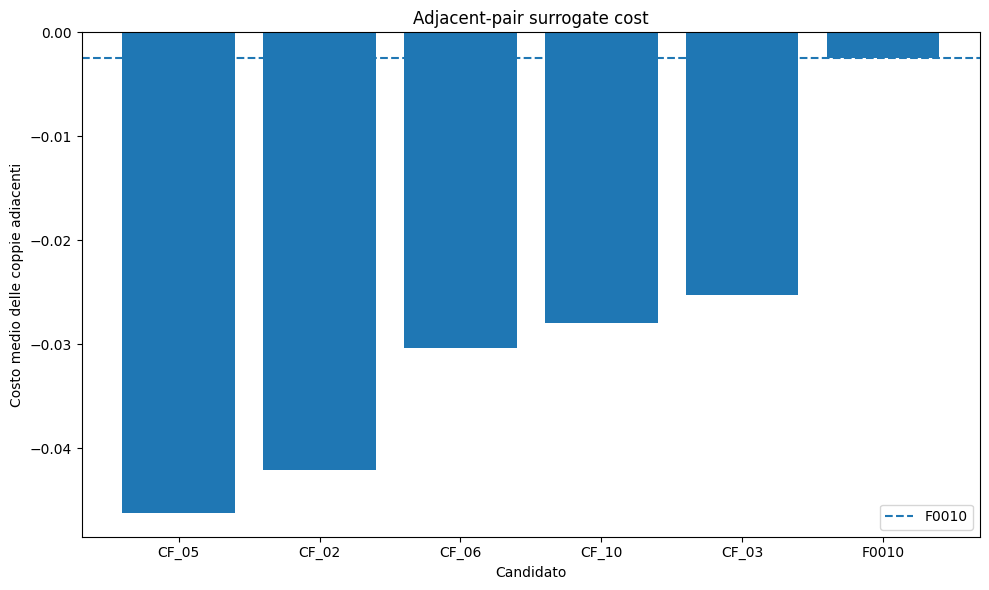

In [28]:
plot_df = candidate_pair_scores.sort_values("pair_total_cost")
plt.figure(figsize=(10,6))
plt.bar(plot_df["candidate_id"], plot_df["pair_total_cost"])
plt.axhline(seed_cost, linestyle="--", label="F0010")
plt.xlabel("Candidato")
plt.ylabel("Costo medio delle coppie adiacenti")
plt.title("Adjacent-pair surrogate cost")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "candidate_pair_total_costs.png", dpi=300, bbox_inches="tight")
plt.show()

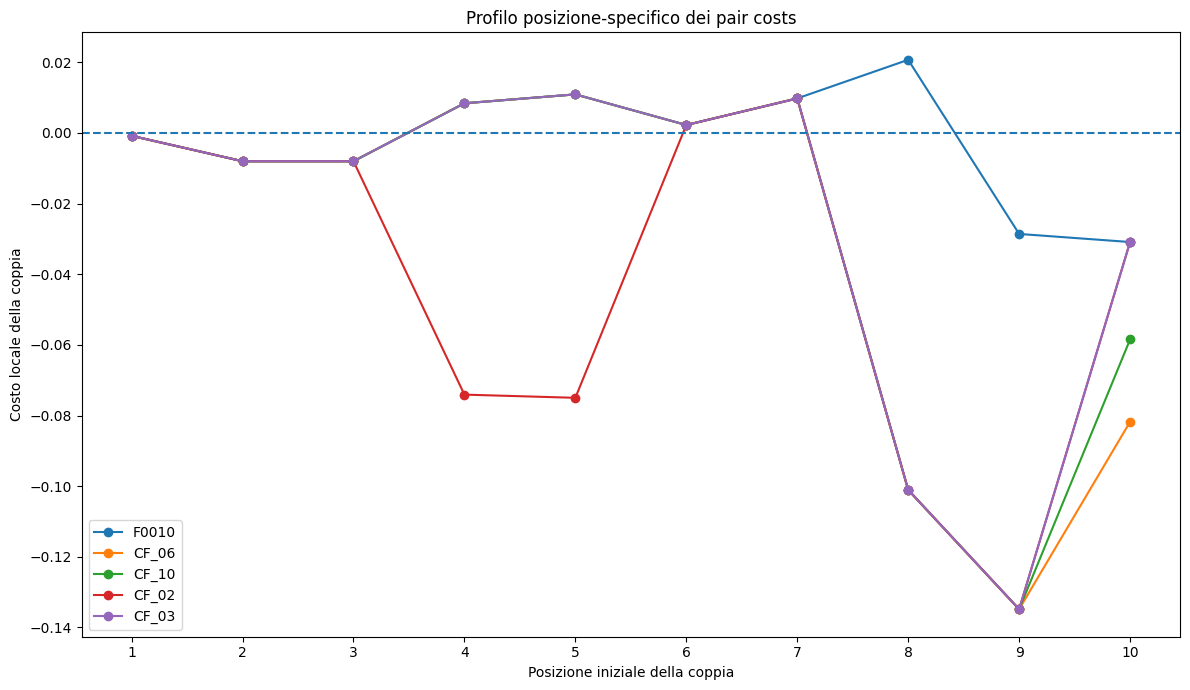

In [29]:
selected_ids = [x for x in ["F0010", "CF_06", "CF_10", "CF_02", "CF_03"] if x in set(pair_contributions["candidate_id"])]
plt.figure(figsize=(12,7))
for candidate_id in selected_ids:
    subset = pair_contributions[pair_contributions["candidate_id"] == candidate_id].sort_values("pair_position_1based")
    plt.plot(subset["pair_position_1based"], subset["pair_cost"], marker="o", label=candidate_id)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Posizione iniziale della coppia")
plt.ylabel("Costo locale della coppia")
plt.title("Profilo posizione-specifico dei pair costs")
plt.xticks(range(1, len(SEED_SEQUENCE)))
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "position_specific_pair_cost_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Esportazione

In [30]:
PAIR_STATISTICS_CSV = RESULT_DIR / "adjacent_pair_score_matrix.csv"
CANDIDATE_SCORES_CSV = RESULT_DIR / "candidate_pairwise_scores.csv"
PAIR_CHANGES_CSV = RESULT_DIR / "pairwise_changes_vs_seed.csv"
ALTERNATIVES_CSV = RESULT_DIR / "position_specific_pair_rankings.csv"
CONTRIBUTIONS_CSV = RESULT_DIR / "candidate_pair_contributions.csv"
INTEGRATED_CSV = RESULT_DIR / "pair_scores_with_foldx_rosetta.csv"
CORRELATIONS_CSV = RESULT_DIR / "pair_score_correlations.csv"
SEED_ALTERNATIVES_CSV = RESULT_DIR / "seed_pair_best_alternatives.csv"
METADATA_JSON = RESULT_DIR / "05e_run_metadata.json"

pair_statistics.to_csv(PAIR_STATISTICS_CSV, index=False)
candidate_pair_scores.to_csv(CANDIDATE_SCORES_CSV, index=False)
changed_pairs.to_csv(PAIR_CHANGES_CSV, index=False)
position_specific_alternatives.to_csv(ALTERNATIVES_CSV, index=False)
pair_contributions.to_csv(CONTRIBUTIONS_CSV, index=False)
integrated_results.to_csv(INTEGRATED_CSV, index=False)
pair_correlations.to_csv(CORRELATIONS_CSV, index=False)
seed_pair_table.to_csv(SEED_ALTERNATIVES_CSV, index=False)

metadata = {
    "seed_id": SEED_ID,
    "seed_sequence": SEED_SEQUENCE,
    "dataset_04c": str(DATASET_04C),
    "target_column": TARGET_COLUMN,
    "sequence_column": SEQUENCE_COLUMN,
    "n_variants": len(dataset),
    "n_pair_observations": len(pair_observations),
    "n_unique_position_pairs": len(pair_statistics),
    "pair_shrinkage_alpha": PAIR_SHRINKAGE_ALPHA,
    "min_pair_support": MIN_PAIR_SUPPORT,
    "normalized_by_length": NORMALIZE_TOTAL_BY_LENGTH,
    "interpretation": "Lower pair cost is more favorable; empirical surrogate, not absolute physical energy."
}
METADATA_JSON.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

for path in [PAIR_STATISTICS_CSV, CANDIDATE_SCORES_CSV, PAIR_CHANGES_CSV,
             ALTERNATIVES_CSV, CONTRIBUTIONS_CSV, INTEGRATED_CSV,
             CORRELATIONS_CSV, SEED_ALTERNATIVES_CSV, METADATA_JSON]:
    print("Salvato:", path.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/adjacent_pair_score_matrix.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/candidate_pairwise_scores.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/pairwise_changes_vs_seed.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/position_specific_pair_rankings.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/candidate_pair_contributions.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/pair_scores_with_foldx_rosetta.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/pair_score_correlations.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/seed_pair_best_alternatives.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacen

## 16. Report automatico

In [31]:
best = candidate_pair_scores.iloc[0] if not candidate_pair_scores.empty else None
report = f"""# 05e — Adjacent amino acid pair energy scoring

## Definizione
Costo empirico posizione-specifico delle coppie adiacenti. Valori inferiori indicano coppie più favorevoli rispetto alle alternative osservate alla stessa posizione.

## Dataset
- Varianti utilizzate: {len(dataset)}
- Target: `{TARGET_COLUMN}`
- Coppie posizione-specifiche osservate: {len(pair_statistics)}
- Shrinkage alpha: {PAIR_SHRINKAGE_ALPHA}

## Miglior candidato secondo il pair score
- ID: {best['candidate_id'] if best is not None else 'N/A'}
- Sequenza: `{best['sequence'] if best is not None else 'N/A'}`
- Pair cost: {best['pair_total_cost'] if best is not None else float('nan'):.6f}
- Delta rispetto a F0010: {best['delta_pair_cost_vs_seed'] if best is not None else float('nan'):.6f}

## Interpretazione
Il pair score è una decomposizione empirica e interpretabile del target locale 04c. Non equivale a una decomposizione FoldX/Rosetta in kcal/mol e non sostituisce la validazione strutturale.

## Output principale
`{CANDIDATE_SCORES_CSV}`
"""
REPORT_PATH = REPORTS_DIR / "05e_adjacent_pair_scoring_report.md"
REPORT_PATH.write_text(report, encoding="utf-8")
print(report)
print("Report:", REPORT_PATH.resolve())

# 05e — Adjacent amino acid pair energy scoring

## Definizione
Costo empirico posizione-specifico delle coppie adiacenti. Valori inferiori indicano coppie più favorevoli rispetto alle alternative osservate alla stessa posizione.

## Dataset
- Varianti utilizzate: 539
- Target: `oracle_target_composite_preliminary`
- Coppie posizione-specifiche osservate: 139
- Shrinkage alpha: 3.0

## Miglior candidato secondo il pair score
- ID: CF_05
- Sequenza: `IGERCEYRELK`
- Pair cost: -0.046202
- Delta rispetto a F0010: -0.043775

## Interpretazione
Il pair score è una decomposizione empirica e interpretabile del target locale 04c. Non equivale a una decomposizione FoldX/Rosetta in kcal/mol e non sostituisce la validazione strutturale.

## Output principale
`outputs/clear_adjacent_pair_scoring_05e/candidate_pairwise_scores.csv`

Report: /Users/robertobruzzese/Desktop/venv/outputs/clear_adjacent_pair_scoring_05e/reports/05e_adjacent_pair_scoring_report.md


## 17. Conclusione metodologica

Con questo notebook il requisito è coperto in forma **empirica e posizione-specifica**:

- la funzione di scoring è implementata;
- ogni coppia è confrontata con alternative alla stessa posizione;
- i candidati CLEAR sono confrontati con F0010;
- il risultato è integrato con FoldX e Rosetta;
- la funzione può essere riutilizzata in futuri workflow di docking e ottimizzazione.

La dicitura corretta resta **surrogate energetic pair cost**, non energia fisica assoluta.